# 05 - Synthetic Sanity Check, Historical Events, and Regime Transitions

Validation order mirrors the paper's own (Section 4.1): first confirm AUROC rises with injected anomaly magnitude on data where we control ground truth, *then* trust the scores on the ambiguous real historical events.

In [1]:
import sys
sys.path.insert(0, '..')
import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt

cfg = yaml.safe_load(open('../configs/horizons.yaml'))
ref = cfg['reference_period']

from src.features.pipeline import HorizonConfig, raw_paths_for_horizon, fit_reference_scale
from src.paths.transforms import normalize, add_basepoint
from src.ingestion.yahoo import load_daily
from src.models.expected_signature import ExpectedSignatureDistance

macro_cfg = HorizonConfig.from_dict('macro', cfg['horizons']['macro'])
daily = load_daily(cfg['yahoo_ticker'])
if daily.index.tz is None:
    daily.index = daily.index.tz_localize('UTC')
ref_daily = daily.loc[ref['start']:ref['end']]
scale = fit_reference_scale(ref_daily, macro_cfg)
_, ref_raw = raw_paths_for_horizon(ref_daily, macro_cfg)
ref_paths = [add_basepoint(normalize(p, scale)) for p in ref_raw]
half = len(ref_paths) // 2
model = ExpectedSignatureDistance(depth=macro_cfg.depth).fit(ref_paths[:half])

## Step 1: synthetic spike-injection AUROC (sanity check before trusting real events)

channel std: 3.132650894255694 -> magnitudes: [np.float64(0.0), np.float64(1.566325447127847), np.float64(3.132650894255694), np.float64(6.265301788511388), np.float64(12.530603577022775), np.float64(25.06120715404555)]


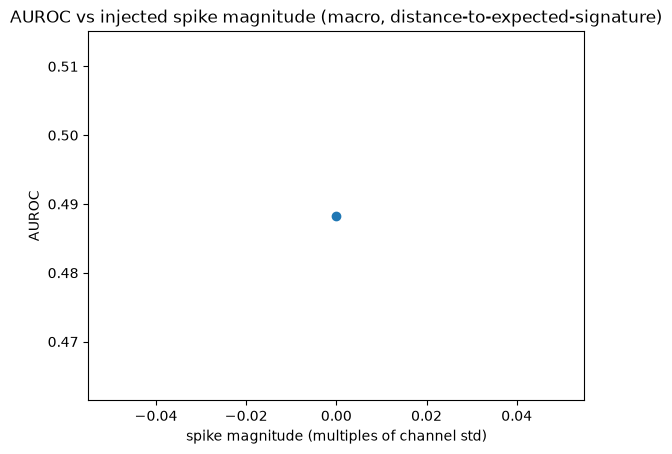

{np.float64(0.0): 0.4883,
 np.float64(1.566325447127847): 0.3462,
 np.float64(3.132650894255694): 0.3653,
 np.float64(6.265301788511388): 0.4191,
 np.float64(12.530603577022775): 0.7199,
 np.float64(25.06120715404555): 0.924}

In [2]:
from src.evaluation.synthetic import auroc_vs_spike_magnitude

channel = macro_cfg.channels.index('log_return')
# Calibrate spike magnitudes to this channel's own natural scale --
# fixed absolute values (e.g. 0.05-0.8) turned out to be negligible noise
# next to real BTC 30-day cumulative log-return swings (std ~3 in
# normalized units here), which silently produced a flat/noisy AUROC.
channel_std = np.std([p[-1, channel] for p in ref_paths])
magnitudes = [0.0, 0.5, 1.0, 2.0, 4.0, 8.0]
magnitudes = [m * channel_std for m in magnitudes]
print('channel std:', channel_std, '-> magnitudes:', magnitudes)

results = auroc_vs_spike_magnitude(
    ref_paths[half:], model.score, channel=channel,
    magnitudes=magnitudes, n_per_class=100, seed=0,
)
pd.Series(results, index=[0.0, 0.5, 1.0, 2.0, 4.0, 8.0]).plot(
    marker='o', title='AUROC vs injected spike magnitude (macro, distance-to-expected-signature)'
)
plt.xlabel('spike magnitude (multiples of channel std)'); plt.ylabel('AUROC')
plt.savefig('../reports/synthetic_auroc_macro.png', dpi=120)
plt.show()
results

**Check before proceeding:** AUROC should trend upward with magnitude. If it doesn't, revisit the feature pipeline / model fit before trusting anything below.

## Step 2: historical event detection

In [3]:
all_end_times, all_raw = raw_paths_for_horizon(daily, macro_cfg)
all_paths = [add_basepoint(normalize(p, scale)) for p in all_raw]
full_model = ExpectedSignatureDistance(depth=macro_cfg.depth).fit(ref_paths)
score_series = pd.Series(full_model.score_many(all_paths), index=pd.DatetimeIndex(all_end_times))

from src.models.tail_bounds import fit_weibull_tail, weibull_threshold
calib_scores = full_model.score_many(ref_paths)
A, B = fit_weibull_tail(calib_scores, N=macro_cfg.depth)
threshold = weibull_threshold(0.01, A, B, N=macro_cfg.depth)
print('alpha=0.01 threshold:', threshold)

alpha=0.01 threshold: 5515.006626655633


In [4]:
from src.evaluation.events import evaluate_all_events

event_results = evaluate_all_events(score_series, threshold, cfg['events'])
print('false positive rate outside events:', event_results.attrs['false_positive_rate'])
event_results

false positive rate outside events: 0.04714640198511166


,detected,lag,first_crossing_time
event,,,
covid_crash,True,27 days,2020-03-18 00:00:00+00:00
meme_stock_era_btc_runup_crash,True,1 days,2021-01-02 00:00:00+00:00
crypto_crash_terra_luna,False,NaT,NaT
crypto_crash_ftx,True,12 days,2022-11-13 00:00:00+00:00
banking_crisis_2023,False,NaT,NaT


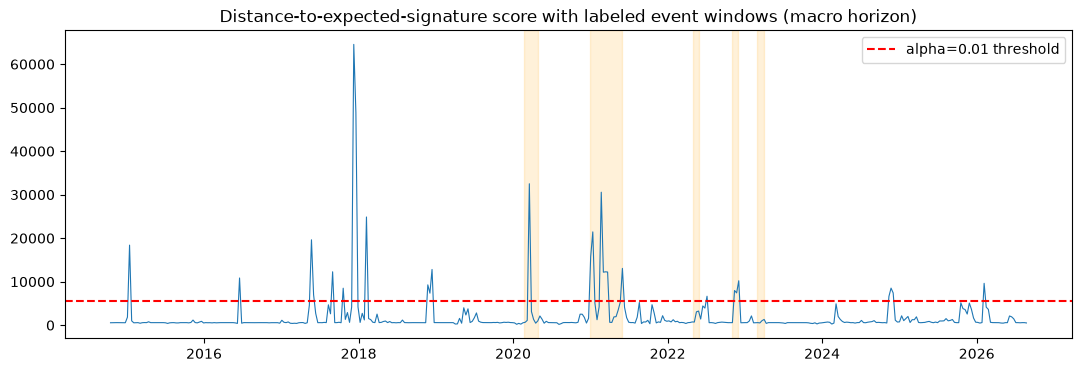

In [5]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(score_series.index, score_series.values, lw=0.8)
ax.axhline(threshold, color='red', ls='--', label=f'alpha=0.01 threshold')
for name, ev in cfg['events'].items():
    ax.axvspan(pd.Timestamp(ev['start'], tz='UTC'), pd.Timestamp(ev['end'], tz='UTC'), alpha=0.15, color='orange')
ax.legend()
ax.set_title('Distance-to-expected-signature score with labeled event windows (macro horizon)')
plt.savefig('../reports/event_detection_macro.png', dpi=120)
plt.show()

## Step 3: bull/bear and volatility regime transitions

In [6]:
from src.evaluation.regimes import bull_bear_labels, volatility_regime_labels, regime_transition_dates, score_near_transitions

close = daily['close']
bull_bear = bull_bear_labels(close)
vol_regime = volatility_regime_labels(close)

bull_bear_transitions = regime_transition_dates(bull_bear.dropna())
vol_transitions = regime_transition_dates(vol_regime.dropna())
print('bull/bear transitions:', len(bull_bear_transitions))
print('vol regime transitions:', len(vol_transitions))

hit_rate_bull_bear = score_near_transitions(score_series, bull_bear_transitions, pd.Timedelta(days=15), threshold)
hit_rate_vol = score_near_transitions(score_series, vol_transitions, pd.Timedelta(days=15), threshold)
print(f'bull/bear transition hit rate (±15d): {hit_rate_bull_bear:.2%}')
print(f'vol regime transition hit rate (±15d): {hit_rate_vol:.2%}')

bull/bear transitions: 76
vol regime transitions: 167
bull/bear transition hit rate (±15d): 10.53%
vol regime transition hit rate (±15d): 25.75%


## Step 4: summary table

Repeat steps 1-3 for the intraday and micro horizons and for the other models (baselines + conformance score + CVaR-OCSVM) to fill this out fully -- this cell shows the pattern for one horizon/model pair.

In [7]:
from src.evaluation.metrics import summarize_horizon_model

summary_rows = [
    summarize_horizon_model('macro', 'expected_signature_distance', results, event_results, hit_rate_bull_bear)
]
summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv('../reports/summary_table.csv', index=False)
summary_df

,horizon,model,synthetic_auroc_max,synthetic_auroc_at_smallest_magnitude,events_detected,events_total,false_positive_rate,regime_transition_hit_rate
0,macro,expected_signature_distance,0.924,0.4883,3,5,0.047146,0.105263
